In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [20]:
iris=datasets.load_iris()
X=iris.data[:,:2]
y=iris.target


In [21]:
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [23]:
models=[
    ("Linear Kernal",SVC(kernel='linear',C=1)),
    ("RBF Kernal(gamma=0.5)",SVC(kernel='rbf',C=1,gamma=0.5)),
    ("RBF Kernal(gamma=5)",SVC(kernel='rbf',C=1,gamma=5)),
    ("polynomial Kernal",SVC(kernel='poly',C=1,gamma=0.5))
]

In [24]:
h=0.02
x_min, x_max=X[:,0].min()-1,X[:,0].max()+1
y_min, y_max=X[:,1].min()-1,X[:,1].max()+1
xx, yy=np.meshgrid(np.arange(x_min,x_max,h),
                   np.arange(y_min,y_max,h))

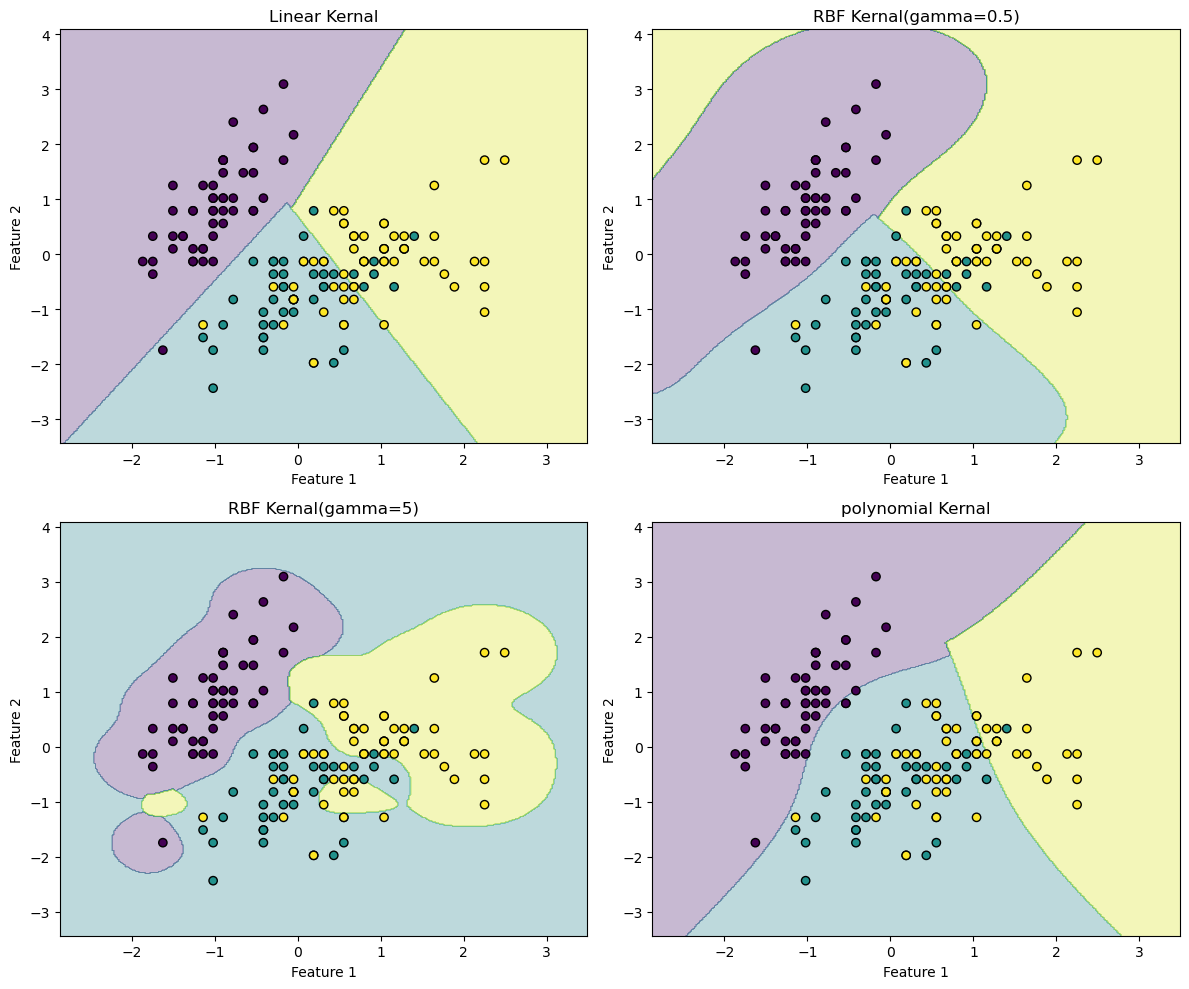

In [25]:
plt.figure(figsize=(12,10))
for i,(title,model) in enumerate(models,1):
   model.fit(X_train,y_train)
   Z=model.predict(np.c_[xx.ravel(),yy.ravel()])
   Z=Z.reshape(xx.shape)
   plt.subplot(2,2,i)
   plt.contourf(xx,yy,Z,alpha=0.3)
   plt.scatter(X[:,0],X[:,1],c=y,edgecolors='k')
   plt.xlabel('Feature 1')
   plt.ylabel('Feature 2')
   plt.title(title)
plt.tight_layout()
plt.show()    

In [26]:
print("Model Performance")
for title,model in models:
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)
    print(f"{title}:{acc:.2f}")

Model Performance
Linear Kernal:0.80
RBF Kernal(gamma=0.5):0.73
RBF Kernal(gamma=5):0.80
polynomial Kernal:0.76


In [27]:
len(model.support_vectors_)

70